# TA Tutorial Session —  IITREICT-AIML-2604 — Classification Metrics: Accuracy, Precision, Recall, and F1-Score

**Academic Session 27** - Accuracy and Precision Metrics, **Academic Session 28** - Recall and F1-Score Metrics, **Assignment:** Accuracy and Precision Metrics -
Objective, Assignment: Accuracy and Precision Metrics - Subjective, Recall and F1-Score Metrics - Objective,  Recall and F1-Score Metrics - Subjective

**Agenda**

1. A quick topic summary to refresh what was covered in the faculty session.
2. 5 objective questions to test your understanding — vote in the chat.
3. 1 scenario-based practice question — these are directly aligned to your assessments, so
pay close attention.
4. An open Q&A block where you can ask anything from the main session or today.

**Context Setting**

**Link to main session:** The faculty sessions covered how to evaluate binary classification models using confusion matrix-derived metrics — accuracy, precision,
recall, and F1-score — using real examples such as defective product detection and forest fire risk identification. Today's tutorial reinforces those concepts and applies them to assessment-style coding problems.

**Why this matters for assessments:** Both the Objective and Subjective assignments
require you to compute these metrics manually from confusion matrix counts and verify
them using scikit-learn functions — skills directly practised in today's session.

# Section 1: Topic-wise Summary

**Topic 1: Confusion Matrix – Foundation of Classification Metrics**

**1. Why Do We Need a Confusion Matrix?**

Suppose you built a machine learning model to detect defective products in a factory.

The model reports: Accuracy = 95%

**Is the model really good ?**

- Not necessarily.

- Maybe it correctly predicts all good products but misses most defective ones.

- To understand where the model makes mistakes, we use a Confusion Matrix.

**2. What is a Confusion Matrix?**

A Confusion Matrix is a table that compares:

Actual Labels
Predicted Labels

It summarizes the model's predictions into four categories:

- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

**3. Confusion Matrix Structure**

| **Actual \ Predicted** | **Positive (1)** | **Negative (0)** |
| ---------------------- | ---------------- | ---------------- |
| **Positive (1)**       | TP               | FN               |
| **Negative (0)**       | FP               | TN               |


- Rows = Actual Class
- Columns = Predicted Class

**Note:** The position of TP, TN, FP, and FN can change depending on how rows and columns are labeled. Always rely on the definitions, not the position in the table.

**4. Understanding TP, TN, FP, FN**

Suppose we are detecting defective products.

- Positive = Defective

- Negative = Good Product

| Term   | Meaning                                | Example            |
| ------ | -------------------------------------- | ------------------ |
| **TP** | Actual defective → Predicted defective | Correct detection  |
| **TN** | Actual good → Predicted good           | Correct prediction |
| **FP** | Actual good → Predicted defective      | False alarm        |
| **FN** | Actual defective → Predicted good      | Missed defect      |


**5. Type-I and Type-II Errors**
Type-I Error (False Positive)
- Actual class = Negative
- Predicted class = Positive

**Example**:

- A good product is incorrectly classified as defective.

- Type-II Error (False Negative)
    - Actual class = Positive
    - Predicted class = Negative

**Example**:

- A defective product is incorrectly classified as good.

- This is usually the more serious error in quality control because defective products may reach customers.

**6. Real-World Example**

| Product | Actual    | Predicted |
| ------- | --------- | --------- |
| 1       | Defective | Defective |
| 2       | Good      | Good      |
| 3       | Defective | Good      |
| 4       | Good      | Defective |
| 5       | Good      | Good      |

**Confusion Matrix:**

| Actual \ Predicted | Defective | Good   |
| ------------------ | --------- | ------ |
| Defective          | TP = 1    | FN = 1 |
| Good               | FP = 1    | TN = 2 |

**7. Python Example**

In [ ]:
from sklearn.metrics import confusion_matrix

# Actual labels
actual = [1, 0, 1, 0, 0]

# Predicted labels
predicted = [1, 0, 0, 1, 0]

cm = confusion_matrix(actual, predicted)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[2 1]
 [1 1]]


**9. Getting TP, TN, FP, FN Directly**

In [ ]:
from sklearn.metrics import confusion_matrix

actual = [1, 0, 1, 0, 0]
predicted = [1, 0, 0, 1, 0]

cm = confusion_matrix(actual, predicted)

TN, FP, FN, TP = cm.ravel()

print("True Positive :", TP)
print("True Negative :", TN)
print("False Positive:", FP)
print("False Negative:", FN)

True Positive : 1
True Negative : 2
False Positive: 1
False Negative: 1


## Topic 2: Accuracy – Measuring Overall Correctness

**1. What is Accuracy ?**

Accuracy measures the percentage of correct predictions made by the model.

It considers both:

- Correct Positive Predictions (TP)
- Correct Negative Predictions (TN)

Accuracy tells us how often the model is correct.

**2. Accuracy Formula**

**Accuracy** = TP+TN / TP+TN+FP+FN

Where:

- TP = True Positive
- TN = True Negative
- FP = False Positive
- FN = False Negative

In [ ]:
# Python Example
from sklearn.metrics import accuracy_score

# Actual labels
actual = [1, 0, 1, 0, 1]

# Predicted labels
predicted = [1, 0, 0, 0, 1]

accuracy = accuracy_score(actual, predicted)

print("Accuracy =", accuracy)
print("Accuracy (%) =", accuracy * 100)

Accuracy = 0.8
Accuracy (%) = 80.0


In [ ]:
# Manual Accuracy in Python

TP = 2
TN = 2
FP = 0
FN = 1

accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Accuracy =", round(accuracy, 2))

Accuracy = 0.8


**When is Accuracy a Good Metric?**

Accuracy is reliable when the dataset is balanced, meaning both classes have a similar number of samples.

**Example**

| Class | Count |
| ----- | ----: |
| Pass  |    50 |
| Fail  |    50 |

Here, Accuracy gives a meaningful measure of performance.


**Why Can Accuracy Be Misleading?**

Suppose a factory inspects 500 products:

- 485 Good
- 15 Defective

A model predicts every product as Good.

Then:

- Correct Predictions = 485
- Total Products = 500
- Accuracy = 485 / 500 = =97%

Although the model has 97% Accuracy, it failed to detect all defective products.

So the model is not useful, despite its high accuracy. This is why the tutorial warns that accuracy alone can be misleading for imbalanced datasets.

**Balanced vs Imbalanced Dataset**

| Balanced Dataset                      | Imbalanced Dataset               |
| ------------------------------------- | -------------------------------- |
| Equal number of samples in each class | One class dominates the other    |
| Accuracy is meaningful                | Accuracy can be misleading       |
| Example: 50 Pass / 50 Fail            | Example: 485 Good / 15 Defective |


In [ ]:
# Complete Python Program
from sklearn.metrics import confusion_matrix, accuracy_score

# Actual and predicted labels
actual = [1, 0, 1, 0, 1]
predicted = [1, 0, 0, 0, 1]

# Confusion Matrix
cm = confusion_matrix(actual, predicted)

print("Confusion Matrix")
print(cm)

# Accuracy using sklearn
accuracy = accuracy_score(actual, predicted)

print("\nAccuracy (sklearn):", round(accuracy, 2))

# Manual Accuracy
TN, FP, FN, TP = cm.ravel()

manual_accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Accuracy (Manual):", round(manual_accuracy, 2))

Confusion Matrix
[[2 0]
 [1 2]]

Accuracy (sklearn): 0.8
Accuracy (Manual): 0.8


**Topic 3: Precision – How Accurate Are the Positive Predictions?**

**1. What is Precision?**

**Precision measures:** Out of all the samples predicted as Positive, how many are actually Positive?

In simple words,

Precision tells us how trustworthy the model's positive predictions are.

**2. Precision Formula**
Precision = TP / TP+FP

Where:

- TP = True Positive
- FP = False Positive

**3. Example (Manual Calculation)**

Suppose a spam detection model predicts:

- TP = 80
- FP = 20

**Step 1:** Total Predicted Positive
TP + FP = 80 + 20 = 100

**Step 2:** Calculate Precision
 - = 80 / 80+20
- = 80 / 100          
- =0.80

Precision = 80%

**4. Interpretation**

A Precision of 80% means: Out of every 100 emails predicted as spam, 80 are actually spam, while 20 are normal emails incorrectly marked as spam.

In [ ]:
# 5. Python Example
from sklearn.metrics import precision_score

# Actual labels
actual = [1, 0, 1, 1, 0, 1]

# Predicted labels
predicted = [1, 1, 1, 0, 0, 1]

precision = precision_score(actual, predicted)

print("Precision =", round(precision, 2))

Precision = 0.75


In [ ]:
# 6. Manual Calculation in Python
from sklearn.metrics import confusion_matrix

actual = [1, 0, 1, 1, 0, 1]
predicted = [1, 1, 1, 0, 0, 1]

cm = confusion_matrix(actual, predicted)

TN, FP, FN, TP = cm.ravel()

precision = TP / (TP + FP)

print("TP =", TP)
print("FP =", FP)
print("Precision =", round(precision, 2))

TP = 3
FP = 1
Precision = 0.75


In [ ]:
# Complete Python Program
from sklearn.metrics import (
    confusion_matrix,
    precision_score
)

actual = [1, 0, 1, 1, 0, 1]
predicted = [1, 1, 1, 0, 0, 1]

cm = confusion_matrix(actual, predicted)

TN, FP, FN, TP = cm.ravel()

precision_manual = TP / (TP + FP)
precision_sklearn = precision_score(actual, predicted)

print("Confusion Matrix")
print(cm)

print("\nTP =", TP)
print("FP =", FP)

print("\nManual Precision :", round(precision_manual, 2))
print("Sklearn Precision:", round(precision_sklearn, 2))

Confusion Matrix
[[1 1]
 [1 3]]

TP = 3
FP = 1

Manual Precision : 0.75
Sklearn Precision: 0.75


**7. Accuracy vs Precision**
| Accuracy                             | Precision                                    |
| ------------------------------------ | -------------------------------------------- |
| Measures overall correct predictions | Measures correctness of positive predictions |
| Uses TP, TN, FP, FN                  | Uses only TP and FP                          |
| Good for balanced datasets           | Useful when False Positives are costly       |


**8. When Should We Use Precision?**

Use Precision when False Positives are expensive.
| Application                | Why Precision?                               |
| -------------------------- | -------------------------------------------- |
| Spam Email Detection       | Don't send genuine emails to the spam folder |
| Loan Approval              | Don't approve loans for risky customers      |
| Face Unlock                | Don't unlock for the wrong person            |
| Fingerprint Authentication | Don't authenticate an unauthorized user      |


**Topic 4: Recall (Sensitivity) – How Many Actual Positives Did the Model Find ?**

**1. What is Recall?**

Out of all the actual positive samples, how many did the model correctly identify?

In simple words, Recall tells us how good the model is at finding all the positive cases.

**2. Recall Formula**

**Recall** = TP / TP+FN

Where:

- **TP** = True Positive
- **FN** = False Negative

**3. Example (Manual Calculation)**

Suppose a disease detection model gives:

TP = 90, FN = 10

**Step 1:** Total Actual Positive Cases
TP + FN = 90 + 10 = 100
**Step 2:** Calculate Recall

- Recall = 90 / 90+10
- = 90 / 100
- =0.90

**Recall = 90%**

**4. Interpretation**

A Recall of 90% means: Out of 100 patients who actually have the disease, the model correctly detected 90 and missed 10.

**5. Real-World Example** - Disease Detection

**Suppose**:
- 100 patients actually have cancer.
- The model correctly detects 95 patients.
- It misses 5 patients.
TP = 95, FN = 5,
- Recall = 95 / 95+5 =
- = 100 / 95
- =0.95

**Recall = 95%**

A high Recall means very few patients are missed.

In [ ]:
# python example
from sklearn.metrics import recall_score

# Actual labels
actual = [1, 1, 0, 1, 0, 1]

# Predicted labels
predicted = [1, 0, 0, 1, 0, 1]

recall = recall_score(actual, predicted)

print("Recall =", round(recall, 2))

Recall = 0.75


In [ ]:
# Manual Calculation in Python
from sklearn.metrics import confusion_matrix

actual = [1, 1, 0, 1, 0, 1]
predicted = [1, 0, 0, 1, 0, 1]

cm = confusion_matrix(actual, predicted)

TN, FP, FN, TP = cm.ravel()

recall = TP / (TP + FN)

print("TP =", TP)
print("FN =", FN)
print("Recall =", round(recall, 2))

TP = 3
FN = 1
Recall = 0.75


In [ ]:
# complete python code
from sklearn.metrics import (
    confusion_matrix,
    recall_score
)

actual = [1, 1, 0, 1, 0, 1]
predicted = [1, 0, 0, 1, 0, 1]

cm = confusion_matrix(actual, predicted)

TN, FP, FN, TP = cm.ravel()

manual_recall = TP / (TP + FN)
sklearn_recall = recall_score(actual, predicted)

print("Confusion Matrix")
print(cm)

print("\nTP =", TP)
print("FN =", FN)

print("\nManual Recall :", round(manual_recall, 2))
print("Sklearn Recall:", round(sklearn_recall, 2))

Confusion Matrix
[[2 0]
 [1 3]]

TP = 3
FN = 1

Manual Recall : 0.75
Sklearn Recall: 0.75


**Precision vs Recall**
| Precision                                         | Recall                                       |
| ------------------------------------------------- | -------------------------------------------- |
| Out of predicted positives, how many are correct? | Out of actual positives, how many are found? |
| Affected by False Positives (FP)                  | Affected by False Negatives (FN)             |
| Important when FP is costly                       | Important when FN is costly                  |


**Accuracy vs Precision vs Recall**
| Metric    | Formula                     | Focus                             |
| --------- | --------------------------- | --------------------------------- |
| Accuracy  | (\frac{TP+TN}{TP+TN+FP+FN}) | Overall correct predictions       |
| Precision | (\frac{TP}{TP+FP})          | Quality of positive predictions   |
| Recall    | (\frac{TP}{TP+FN})          | Coverage of actual positive cases |


**Topic 5: F1-Score – Balancing Precision and Recall**

**1. Why Do We Need F1-Score?**

Sometimes, a model has:

High Precision but Low Recall, or
High Recall but Low Precision

Which model is better?

Instead of looking at two separate metrics, we use F1-Score, which combines both into a single value.

**2. What is F1-Score?**

F1-Score is the harmonic mean of Precision and Recall.

It provides a balanced measure of model performance.

F1-Score tells us how well the model balances Precision and Recall.

**3. F1-Score Formula**

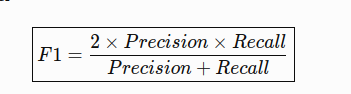

**4. Real-World Example**

Face Recognition System

Suppose
- Precision = 95%, Recall = 90%

Then,

**F1 score**
 -  =  2×0.95×0.90 / 0.95+0.90
- 	​=0.924

**F1-Score = 92.4%**

This means the system not only identifies the correct person accurately (high Precision) but also recognizes most genuine users (high Recall).

In [ ]:
# 7. Python Example
from sklearn.metrics import f1_score

# Actual labels
actual = [1, 1, 0, 1, 0, 1]

# Predicted labels
predicted = [1, 0, 0, 1, 0, 1]

f1 = f1_score(actual, predicted)

print("F1-Score =", round(f1, 2))

F1-Score = 0.86


In [ ]:
# 8. Manual Calculation in Python
from sklearn.metrics import confusion_matrix

actual = [1, 1, 0, 1, 0, 1]
predicted = [1, 0, 0, 1, 0, 1]

cm = confusion_matrix(actual, predicted)

TN, FP, FN, TP = cm.ravel()

precision = TP / (TP + FP)
recall = TP / (TP + FN)

f1 = 2 * precision * recall / (precision + recall)

print("Precision :", round(precision, 2))
print("Recall    :", round(recall, 2))
print("F1-Score  :", round(f1, 2))

Precision : 1.0
Recall    : 0.75
F1-Score  : 0.86


In [ ]:
# 9. Complete Python Program
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

actual = [1, 1, 0, 1, 0, 1]
predicted = [1, 0, 0, 1, 0, 1]

precision = precision_score(actual, predicted)
recall = recall_score(actual, predicted)
f1 = f1_score(actual, predicted)

print("Precision :", round(precision, 2))
print("Recall    :", round(recall, 2))
print("F1-Score  :", round(f1, 2))

Precision : 1.0
Recall    : 0.75
F1-Score  : 0.86


**10. Accuracy vs Precision vs Recall vs F1-Score**

| Metric    | Focus                                |
| --------- | ------------------------------------ |
| Accuracy  | Overall correct predictions          |
| Precision | Correctness of predicted positives   |
| Recall    | Ability to detect actual positives   |
| F1-Score  | Balance between Precision and Recall |


**Topic 6: When to Prioritize Precision vs Recall**

**1. Why Can't We Always Maximize Both?**

In many real-world problems:

Increasing Precision may decrease Recall.
Increasing Recall may decrease Precision.

Therefore, we choose the metric based on the application's requirements.

**2. When to Prioritize Precision**
Use Precision when False Positives (FP) are costly.
Meaning

You want the model to predict Positive only when it is very confident.

**Examples**
| Application                    | Why Precision?                                |
| ------------------------------ | --------------------------------------------- |
| **Spam Email Detection**       | Don't send genuine emails to the spam folder. |
| **Face Unlock**                | Don't unlock the phone for the wrong person.  |
| **Fingerprint Authentication** | Don't authenticate an unauthorized user.      |
| **Loan Approval**              | Don't approve loans for risky customers.      |




**Example**

Suppose a spam filter predicts:

- 100 emails as Spam
- 95 are actually Spam
- 5 are normal emails
- Precision = 95%

This means the model makes very few False Positive errors.

**3. When to Prioritize Recall**
Use Recall when False Negatives (FN) are costly.

**Meaning**

You want the model to detect as many positive cases as possible, even if it makes a few false alarms.

**Examples**

| Application             | Why Recall?                         |
| ----------------------- | ----------------------------------- |
| **Disease Detection**   | Don't miss sick patients.           |
| **Cancer Screening**    | Detect every possible patient.      |
| **Fraud Detection**     | Catch every fraudulent transaction. |
| **Fire Alarm System**   | Detect every fire.                  |
| **Intrusion Detection** | Detect every cyber attack.          |


**Example**

Suppose:

- 100 patients actually have a disease.
- Model detects 98 patients.
- Misses only 2 patients.
- Recall = 98%

This means the model has very few False Negative errors.

**4. Precision vs Recall**
| Precision                      | Recall                       |
| ------------------------------ | ---------------------------- |
| Focuses on predicted positives | Focuses on actual positives  |
| Reduces False Positives (FP)   | Reduces False Negatives (FN) |
| Used when FP is costly         | Used when FN is costly       |
| Example: Spam Detection        | Example: Disease Detection   |


In [ ]:
# Python Example
from sklearn.metrics import precision_score, recall_score

actual = [1, 1, 1, 0, 0, 1, 0, 1]
predicted = [1, 1, 0, 0, 1, 1, 0, 1]

precision = precision_score(actual, predicted)
recall = recall_score(actual, predicted)

print("Precision :", round(precision, 2))
print("Recall    :", round(recall, 2))

Precision : 0.8
Recall    : 0.8


**Summary Table**
| Application          | Priority  | Reason                           |
| -------------------- | --------- | -------------------------------- |
| Spam Email Detection | Precision | Avoid False Positives            |
| Face Unlock          | Precision | Prevent unauthorized access      |
| Loan Approval        | Precision | Avoid approving risky applicants |
| Disease Detection    | Recall    | Avoid missing patients           |
| Cancer Detection     | Recall    | Detect every possible patient    |
| Fraud Detection      | Recall    | Catch every fraud case           |
| Fire Alarm System    | Recall    | Detect every fire                |


**Key Takeaways**
- Precision is important when you want to avoid False Positives, such as in spam detection, face authentication, and loan approval.
- Recall is important when you want to avoid False Negatives, such as in disease diagnosis, fraud detection, and fire alarm systems.
- The choice between Precision and Recall depends on which type of error has the greater real-world cost, as emphasized in the tutorial.

# Section 2: Objective Questions

### Question 1

A machine learning team compares three tuned variants of the same fire-risk model: a
recall-focused variant (false negatives pushed toward zero at the cost of more false
positives, F1 = 0.667), a precision-focused variant (fewer false positives at the cost of more
false negatives, F1 = 0.57), and a balanced variant (TP=7, FN=3, FP=2, TN=13, giving
recall = 0.7, precision = 0.778, F1 = 0.737). Based on these results, which conclusions are
correct? Type: MSQ Options:
1. The recall-focused variant automatically has the highest F1-score overall, simply
because it records the highest recall value among the three
2. The balanced variant has the highest F1-score of the three, despite neither of its metrics
being the single highest
3. The precision-focused variant's low F1 of 0.57 shows pushing precision higher while
recall falls further does not raise the score
4. All three variants must produce exactly equal F1-scores, since they are simply
threshold-tuned versions of the same underlying model

<details><summary><b>Answer & explanation</b></summary>

**Correct: 2.** The balanced variant has the highest F1-score of the three, despite neither of its
metrics being the single highest,** 3. **The precision-focused variant's low F1 of 0.57 shows
pushing precision higher while recall falls further does not raise the score
Explanation: The balanced variant achieves the highest F1-score (0.737) of the three even
though neither its
recall (0.7) nor its precision (0.778) is the single highest value recorded across all
variants — F1 rewards both metrics being simultaneously high rather than one metric
alone.
- A) This is incorrect because F1 is not determined by a single metric; the recall-focused
variant's F1 (0.667) is actually lower than the balanced variant's F1 (0.737), showing
that
having the highest recall alone does not guarantee the highest F1.
- **B) Correct.** The balanced variant's F1 of 0.737 is the highest of the three, illustrating
that the strongest combined score comes from both metrics being reasonably high
together.
- **C) Correct.** The precision-focused variant's F1 of only 0.57, despite very high precision,
demonstrates that driving precision up while recall keeps falling does not raise the
combined
score, since F1 leans toward the weaker metric.
- D) This is incorrect because the three variants were deliberately tuned to different
thresholds, producing different confusion-matrix counts and therefore different F1-
scores.

### Question 2
A product manager at a busy cancer-diagnosis hospital is deciding how to tune a
diagnosis classification model's threshold. Senior doctors have very limited bandwidth, and
only cases that are genuinely urgent should be escalated directly to them; junior doctors
handle everything else. Which threshold strategy should the team implement? Type: SCQ
Options:
1. Lower the classification threshold below 0.5 to favor high recall, so as many potential
cases as possible are flagged
2. Keep the classification threshold fixed at 0.5 regardless of the hospital's staffing
constraints
3. Remove the threshold entirely and classify every instance as positive to avoid missing
any case
4. Raise the classification threshold above 0.5 to favor high precision, so only highly
confident positive predictions are escalated

<details><summary><b>Answer & explanation</b></summary>

**Correct: 4.** Raise the classification threshold above 0.5 to favor high precision, so only
highly confident positive predictions are escalated
Explanation: Raising the classification threshold makes the model more conservative about
flagging a case
positive, which increases precision — exactly what is needed here, since a flagged case
must
be genuinely malignant before it reaches a scarce senior doctor.
- A) This does the opposite: lowering the threshold favors recall over precision, which
would flood senior doctors with more flagged cases, including less-confident ones — the
wrong
direction for an overloaded triage setting.
- B) This ignores the domain-specific reasoning entirely; the 0.5 default is a neutral
middle ground, not a fit tuned for this hospital's staffing situation.
- C) This is an extreme, unworkable choice — classifying everything positive would defeat
the purpose of triage and send every patient to senior doctors regardless of urgency.
- **D) Correct.** Raising the threshold favors precision, ensuring only highly confident cases
are escalated to scarce senior doctors.

### Question 3
A backend engineer wants to compute precision with scikit-learn for a defective-versus-
good classifier, where "defective" is encoded as label 1 and is the class of interest. Which
approach correctly reproduces the manual precision calculation without unnecessary steps?
Type: SCQ Options:
1. Call precision_score(actual_y, predicted_y, pos_label=0) , so that good is treated as
the positive class instead of defective.
2. Call precision_score(actual_y, predicted_y) directly, since defective is already
encoded as label 1, the function's default positive label.
3. Reorder the arrays so that all defective items appear first, then call precision_score
without any labels argument.
4. Call confusion_matrix(actual_y, predicted_y) without specifying labels, since row and
column order does not affect the returned precision value.

<details><summary><b>Answer & explanation</b></summary>

**Correct: 2.** Call precision_score(actual_y, predicted_y) directly, since defective is already
encoded as label 1, the function's default positive label.
Explanation: Because defective is encoded as 1, calling precision_score(actual_y,
predicted_y) directly uses the function's default positive label and reproduces the same
result as the manual TP / (TP + FP) calculation — no extra arguments are needed.
A) Incorrect — setting pos_label=0 would compute precision for the "good" class,
which is not the class of interest and would not match the manual calculation for
defective items.
**B) Correct** — precision_score(actual_y, predicted_y) directly uses scikit-learn's
default positive label of 1, which already matches "defective," so no extra arguments are
needed.
C) Incorrect — precision_score already pairs each actual value with its corresponding
predicted value positionally; reordering both arrays together changes nothing and is an
unnecessary, confusing extra step.
D) Incorrect — confusion_matrix returns a matrix, not a precision value at all, so it
cannot substitute for calling precision_score ; the claim about label order also
misapplies a confusion-matrix-layout fact to a function that does not compute precision.

### Question 4

A researcher compares two classifiers — a logistic regression model and a decision tree
model — both trained on a breast-cancer dataset (malignant = positive, benign = negative,
212 malignant vs. 357 benign out of 569 total instances). The researcher wants to
understand how raising the classification threshold affects precision for each model. Which
of the following statements are correct? Type: MSQ Options:
1. The logistic regression model's threshold can be raised from the default 0.5 toward 0.9
because it outputs a continuous score between 0 and 1 for each instance.
2. Raising the logistic regression threshold from 0.5 to 0.9 is expected to decrease
precision toward 0.92, based on the observed pattern in the accuracy-versus-threshold
results.
3. The decision tree's threshold cannot be manipulated the same way, since decision trees
do not produce a probability-like score; its confusion matrix comes directly from
comparing actual and predicted labels.
4. Because this dataset is comparatively balanced (212 malignant vs. 357 benign),
accuracy remains a comparatively trustworthy metric for it, unlike a highly imbalanced
dataset.

<details><summary><b>Answer & explanation</b></summary>

**Correct: 1.** The logistic regression model's threshold can be raised from the default 0.5
toward 0.9 because it outputs a continuous score between 0 and 1 for each instance., **3.** The
decision tree's threshold cannot be manipulated the same way, since decision trees do not
produce a probability-like score; its confusion matrix comes directly from comparing actual
and predicted labels., **4.** Because this dataset is comparatively balanced (212 malignant vs.
357 benign), accuracy remains a comparatively trustworthy metric for it, unlike a highly
imbalanced dataset.
Explanation: This scenario tests whether the threshold-tuning mechanics and the
accuracy/precision table are being read carefully together.
- **A) Correct** — logistic-regression-style classifiers output continuous scores between 0
and 1, which is exactly what makes threshold tuning (e.g., moving from 0.5 to 0.9)
possible.
- B) Incorrect — this swaps the two metrics; as the threshold rises toward 0.9, precision
climbs toward and holds at 1.00 (not 0.92), while it is accuracy that drops toward
roughly 0.92 as more genuine positive cases get missed.
- **C) Correct** — decision trees do not produce this kind of probability-like score for
classification, so their confusion matrix values must come directly from comparing
actual and predicted labels rather than from threshold manipulation.
- **D) Correct** — with 212 malignant and 357 benign instances out of 569 total, this dataset
is comparatively balanced, and accuracy stays informative and trustworthy for it, unlike
a highly skewed dataset.

### Question 5
A senior data analyst raises a fire-risk model's classification threshold from the 0.5
default to 0.7 and observes that precision improves, but the overall F1-score actually drops
compared to before. What most likely explains this outcome? Type: SCQ Options:
1. Recall dropped enough that the harmonic mean pulled F1 down despite higher precision
2. The confusion matrix layout changed, so the TP and TN cell positions swapped without
explanation
3. Accuracy became unreliable because of class imbalance, which directly lowered the F1-
score
4. The model was silently retrained with a different algorithm, changing its underlying
predictions

<details><summary><b>Answer & explanation</b></summary>

**Correct: 1.** Recall dropped enough that the harmonic mean pulled F1 down despite higher
precision
Explanation: Raising the threshold makes the model more conservative, so false positives
shrink and
precision rises — but boundary-case positives that score just below the new threshold get
missed, so false negatives increase and recall drops. Because F1 is the harmonic mean, it
leans toward whichever metric is weaker.
- **A) Correct.** A sharp recall drop pulls the combined F1 score down even while precision
looks better, exactly matching the harmonic mean's behavior.
- B) This is incorrect because confusion-matrix cell positions only depend on how the
rows and columns are labeled, not on threshold changes — adjusting a threshold does
not reorder which
cell is TP versus TN.
- C) This brings in accuracy, a different metric entirely that is not part of the F1
calculation, so it cannot directly explain an F1 change here.
- D) This invents an unrelated cause (retraining with a different algorithm) that was never
part of the scenario, which only involved adjusting the threshold on the same model.

# Section 3: Scenario-based Practice Questions

**Q1.** A machine-learning engineer at a factory has been asked to build a small, reusable evaluation script for a defect-detection classifier. Quality-control staff have manually verified the classifier's predictions for a batch of 10 inspected items and recorded the actual and predicted labels ("defective" = 1 is the positive class, "good" = 0 is the negative class). The engineer must write a Python function that builds the confusion matrix, computes accuracy and precision both manually (from the TP/FN/FP/TN counts) and via scikit-learn's built-in functions, and returns both sets of results so they can be compared
and logged.

**Constraints & Requirements:**

- Use pandas to store the item , actual , and predicted values together in a DataFrame with those three column names, in that order.
- Use sklearn.metrics.confusion_matrix with labels=[1, 0] so that the positive class (defective) is evaluated first, matching the convention used for this dataset.
- Compute accuracy and precision manually from the unpacked TP/FN/FP/TN counts, and also compute them using sklearn.metrics.accuracy_score and sklearn.metrics.precision_score .
- Round every reported metric to 3 decimal places.
- No plotting or visualization is required.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
def evaluate(items, actual, predicted):
# TODO: build a DataFrame with columns "item", "actual", "predicted"
# TODO: compute the confusion matrix with defective (1) as the positive label
# and unpack it into tp, fn, fp, tn in the correct semantic order
# TODO: compute accuracy and precision manually from tp/fn/fp/tn
# TODO: compute accuracy and precision using scikit-learn's built-in functions
# TODO: return a dictionary with tp, fn, fp, tn, manual_accuracy, sk_accuracy,
# manual_precision, and sk_precision (each metric rounded to 3 decimals)
pass
if __name__ == "__main__":
items = list(range(1, 11))
actual = [1, 0, 1, 0, 0, 1, 0, 0, 1, 0]
predicted = [1, 0, 0, 0, 1, 1, 0, 0, 1, 1]
print(evaluate(items, actual, predicted))

In [ ]:
df = pd.DataFrame(

        {"item": items, "actual": actual_labels, "predicted": predicted_labels}

    )

    # 2. Compute confusion matrix with labels=[1, 0]

    # Structure of matrix when labels=[1,0]:

    cm = confusion_matrix(df["actual"], df["predicted"], labels=[1, 0])

    # Unpack counts

    tp, fn, fp, tn = cm.ravel()



In [12]:
import pandas as pd

from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

data = {'actual': [1, 0, 1, 0, 0, 1, 0, 0, 1, 0], 'predicted': [1, 0, 0, 0, 1, 1, 0, 0, 1, 1]}

def evaluate(items, actual, predicted):

    df = pd.DataFrame({'item': items, 'actual': actual, 'predicted': predicted})

    cm = confusion_matrix(actual, predicted, labels=[0, 1])

    tn, fp, fn, tp = cm.ravel()

    total_samples = tp + tn + fp + fn

    manual_accuracy = (tp + tn) / total_samples if total_samples > 0 else 0

    manual_precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    sk_accuracy = accuracy_score(actual, predicted)

    sk_precision = precision_score(actual, predicted, pos_label=1)

    return {

        'tp': round(tp, 3),

        'fn': round(fn, 3),

        'fp': round(fp, 3),

        'tn': round(tn, 3),

        'manual_accuracy': round(manual_accuracy, 3),

        'sk_accuracy': round(sk_accuracy, 3),

        'manual_precision': round(manual_precision, 3),

        'sk_precision': round(sk_precision, 3)

    }
if name == "__main__":mport pandas as pd

from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

data = {'actual': [1, 0, 1, 0, 0, 1, 0, 0, 1, 0], 'predicted': [1, 0, 0, 0, 1, 1, 0, 0, 1, 1]}

def evaluate(items, actual, predicted):

    df = pd.DataFrame({'item': items, 'actual': actual, 'predicted': predicted})

    cm = confusion_matrix(actual, predicted, labels=[0, 1])

    tn, fp, fn, tp = cm.ravel()

    total_samples = tp + tn + fp + fn

    manual_accuracy = (tp + tn) / total_samples if total_samples > 0 else 0

    manual_precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    sk_accuracy = accuracy_score(actual, predicted)

    sk_precision = precision_score(actual, predicted, pos_label=1)

return {

        'tp': round(tp, 3),

        'fn': round(fn, 3),

        'fp': round(fp, 3),

        'tn': round(tn, 3),

        'manual_accuracy': round(manual_accuracy, 3),

        'sk_accuracy': round(sk_accuracy, 3),

        'manual_precision': round(manual_precision, 3),

        'sk_precision': round(sk_precision, 3)

    }

if __name__ == "__main__":

    items = list(range(1, 11))

    actual = [1, 0, 1, 0, 0, 1, 0, 0, 1, 0]

    predicted = [1, 0, 0, 0, 1, 1, 0, 0, 1, 1]

    print(evaluate(items, actual, predicted))


    items = list(range(1, 11))

    actual = [1, 0, 1, 0, 0, 1, 0, 0, 1, 0]

    predicted = [1, 0, 0, 0, 1, 1, 0, 0, 1, 1]

    print(evaluate(items, actual, predicted))


SyntaxError: invalid syntax (3120235438.py, line 44)

**Q2:** Online Shopping – Fake Product Detection
Problem Statement

An e-commerce company has developed a machine learning model to detect fake products listed by sellers.

The model produced the following confusion matrix:

| Actual \ Predicted | Fake | Genuine |
| ------------------ | ---- | ------- |
| **Fake**           | 80   | 20      |
| **Genuine**        | 15   | 185     |

**Questions**
1. Identify the values of TP, TN, FP, and FN.
2. Calculate: Accuracy, Precision, Recall, F1-Score
3. Which type of error occurs more frequently: False Positive or False Negative?
4. In this application, should the company prioritize Precision or Recall? Justify your answer.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ======================================================
# Actual Labels
# 1 = Fake Product
# 0 = Genuine Product
# ======================================================

actual = (
    [1] * 80 +      # TP
    [1] * 20 +      # FN
    [0] * 15 +      # FP
    [0] * 185       # TN
)

predicted = (
    [1] * 80 +      # TP
    [0] * 20 +      # FN
    [1] * 15 +      # FP
    [0] * 185       # TN
)

# ------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------

cm = confusion_matrix(actual, predicted)

TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix")
print(cm)

print("\nTP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)

# ------------------------------------------------------
# Evaluation Metrics
# ------------------------------------------------------

accuracy = accuracy_score(actual, predicted)
precision = precision_score(actual, predicted)
recall = recall_score(actual, predicted)
f1 = f1_score(actual, predicted)

print("\nAccuracy  :", round(accuracy, 4), "=", round(accuracy*100,2), "%")
print("Precision :", round(precision, 4), "=", round(precision*100,2), "%")
print("Recall    :", round(recall, 4), "=", round(recall*100,2), "%")
print("F1-Score  :", round(f1, 4), "=", round(f1*100,2), "%")

# ------------------------------------------------------
# Error Analysis
# ------------------------------------------------------

if FP > FN:
    print("\nMore frequent error: False Positive")
elif FN > FP:
    print("\nMore frequent error: False Negative")
else:
    print("\nFalse Positive and False Negative occur equally.")

# ------------------------------------------------------
# Recommendation
# ------------------------------------------------------

print("\nRecommendation:")
print("Prioritize Precision because incorrectly flagging")
print("a genuine product as fake can unfairly affect")
print("honest sellers and reduce trust in the platform.")